# Gold Star Schema and Marts

Builds facts with point in time dimension joins plus the three serving marts, reconciles the rebuild against stored Gold parquet, and charts the headline numbers.

## Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
SILVER = ROOT / "data" / "silver"
GOLD = ROOT / "data" / "gold"

from src.gold.build import (
    build_fact_orders,
    build_fact_returns,
    mart_ramadan_seasonality,
    mart_return_rate_by_product,
    mart_revenue_by_store_month,
)

print("imports ok")

imports ok


## Build facts

Resolve orders to the customer and employee versions active at order time.

In [2]:
orders = pd.read_parquet(SILVER / "fact_orders.parquet")
customers = pd.read_parquet(SILVER / "dim_customers_scd2.parquet")
employees = pd.read_parquet(SILVER / "dim_employees_scd2.parquet")
facts = build_fact_orders(orders, customers, employees)
returns = build_fact_returns(pd.read_parquet(SILVER / "fact_returns.parquet"), facts)
print(f"orders {len(orders)} -> facts {len(facts)}, returns {len(returns)}")
facts[["order_id", "order_date", "customer_sk", "store_id", "total_revenue"]].head(3)

orders 12000 -> facts 12000, returns 1056

,order_id,order_date,customer_sk,store_id,total_revenue
0,ORD0003830,2022-01-01,2393,4,840.0
1,ORD0001773,2022-01-01,2871,2,1332.0
2,ORD0011987,2022-01-01,2339,11,520.0


## Build marts

Revenue by store month, return rate by product, Ramadan seasonality.

In [3]:
details = pd.read_parquet(SILVER / "fact_order_details.parquet")
dates = pd.read_parquet(SILVER / "dim_date.parquet")
revenue = mart_revenue_by_store_month(facts)
rates = mart_return_rate_by_product(details, returns["order_id"])
ramadan = mart_ramadan_seasonality(facts, dates)
print(
    "revenue mart:",
    revenue.shape,
    "| rates mart:",
    rates.shape,
    "| ramadan mart:",
    ramadan.shape,
)
revenue.head(3)

revenue mart: (540, 5) | rates mart: (345, 4) | ramadan mart: (42, 4)


,store_id,month,revenue,cost,orders
0,1,2022-01,192372.0,156960.0,49
1,1,2022-02,167051.5,129590.0,40
2,1,2022-03,221637.0,182420.0,46


## Reconcile

Rebuilt marts must match the stored Gold parquet row for row.

In [4]:
stored = {
    name: pd.read_parquet(GOLD / f"{name}.parquet")
    for name in [
        "fact_orders",
        "mart_revenue_by_store_month",
        "mart_return_rate_by_product",
        "mart_ramadan_seasonality",
    ]
}
rebuilt = {
    "fact_orders": facts,
    "mart_revenue_by_store_month": revenue,
    "mart_return_rate_by_product": rates,
    "mart_ramadan_seasonality": ramadan,
}
recon = pd.DataFrame(
    [
        {
            "table": name,
            "rebuilt": len(rebuilt[name]),
            "stored": len(stored[name]),
            "match": len(rebuilt[name]) == len(stored[name]),
        }
        for name in rebuilt
    ]
)
print(recon.to_string(index=False))
assert recon["match"].all()

                      table  rebuilt  stored  match
                fact_orders    12000   12000   True
mart_revenue_by_store_month      540     540   True
mart_return_rate_by_product      345     345   True
   mart_ramadan_seasonality       42      42   True


## Monthly revenue

Company wide revenue trend from the revenue mart.

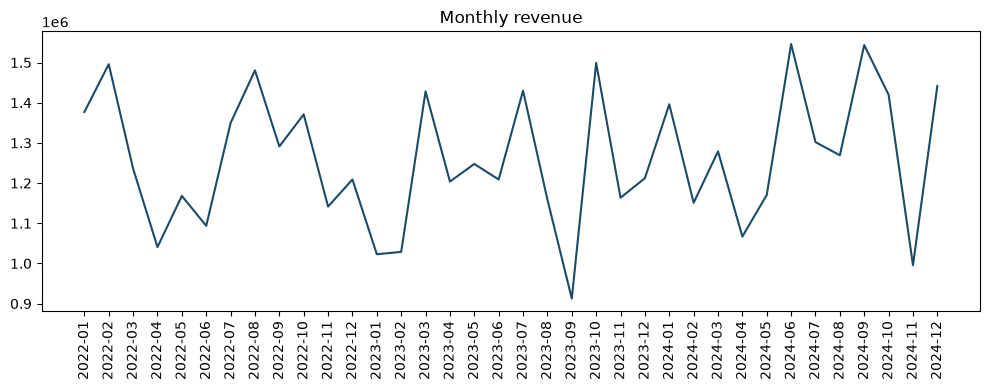

In [5]:
trend = revenue.groupby("month", as_index=False)["revenue"].sum()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(trend["month"], trend["revenue"], color="#1B4B66")
ax.set_title("Monthly revenue")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

## Revenue by store

Ranked store contribution and concentration.

top 3 share: 36.8%


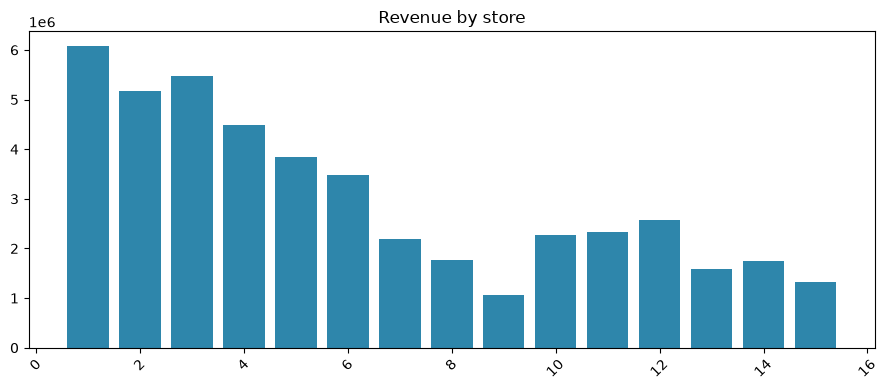

In [6]:
by_store = (
    revenue.groupby("store_id", as_index=False)["revenue"]
    .sum()
    .sort_values("revenue", ascending=False)
)
top3 = by_store.head(3)["revenue"].sum() / by_store["revenue"].sum()
print(f"top 3 share: {top3:.1%}")
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(by_store["store_id"], by_store["revenue"], color="#2E86AB")
ax.set_title("Revenue by store")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## Return rate

Highest return rate products by volume.

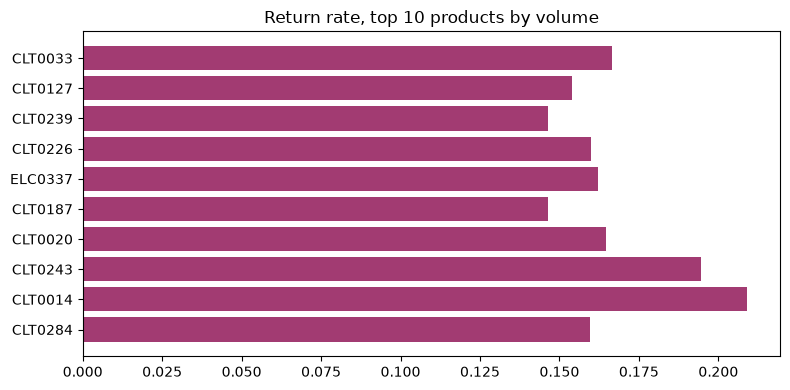

portfolio mean rate: 8.72%


In [7]:
top_ret = rates.sort_values("times_returned", ascending=False).head(10)
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(top_ret["product_id"], top_ret["return_rate"], color="#A23B72")
ax.set_title("Return rate, top 10 products by volume")
plt.tight_layout()
plt.show()
print("portfolio mean rate:", f"{rates['return_rate'].mean():.2%}")

## Ramadan lift

Average monthly revenue inside versus outside Ramadan windows.

 is_ramadan      revenue
          0 1.169632e+06
          1 5.407074e+05


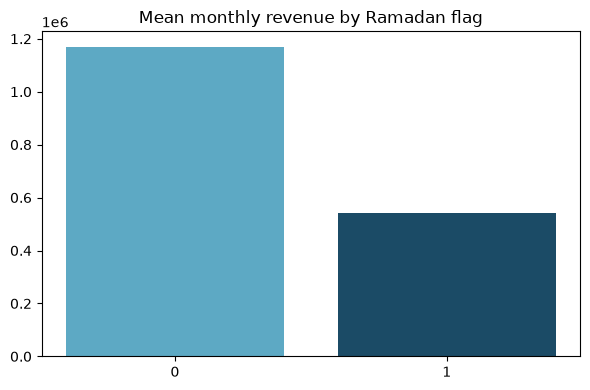

In [8]:
lift = ramadan.groupby("is_ramadan", as_index=False)["revenue"].mean()
print(lift.to_string(index=False))
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(lift["is_ramadan"].astype(str), lift["revenue"], color=["#5DA9C4", "#1B4B66"])
ax.set_title("Mean monthly revenue by Ramadan flag")
plt.tight_layout()
plt.show()

## Takeaways

Facts join as of order date, marts reconcile with stored Gold, and revenue, concentration, returns, and seasonality all read from one governed set of tables.